# Apparatus inertia calibration - exploration

**Goal:** before wiring the apparatus-inertia correction into the CLI / GUI / exporter, confirm that the relationship `I_apparatus(aor, width)` recovered from the empty-apparatus dynamic runs is physically sensible and accurate enough to trust.

- `aor` = axis-of-rotation-to-clamp distance (mm)
- `width` = plate-to-plate span (mm), recorded as `calibration_inertia_apparatus_plate_to_plate_millimeter`

**aor values:** the empty-apparatus files recorded `aor = NaN` (routing bug, since fixed). The real per-file `aor` values below are transcribed from the lab-notes photo `2026_07_06_apparatus_calibration_notes.heic`, which lays out a 3x3 factorial: `aor in {7, 18, 29} mm` (rows) x `width in {~52, ~91, 133} mm` (columns), with replicates. File `_09_` (aor 7, width 133) is excluded - the notes mark it 'hits the gripper, too wide' and its per-trial R2 is ~0.02.

Fit forms compared:

- **F1** `I = a + b*aor^2` (parallel-axis, width ignored)
- **F2** `I = a + b*aor + c*aor^2`
- **F3** `I = a + b*aor^2 + c*width`
- **F4** `I = a + b*aor^2 + c*width^2` (unconstrained separable quadratic)
- **F5** `I = a + b*(aor^2 + (width/2)^2)` (Pythagorean single-mass geometry; aor^2:width^2 locked at 4:1)

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bender_functions import (
    fit_apparatus_inertia_calibration,
    extract_apparatus_inertia_trial,
    apparatus_inertia_from_fit,
    _apparatus_fit_design_row,
    _APPARATUS_FIT_TERMS,
)

CAL_DIR = (
    '/Users/yjimenez/Library/CloudStorage/OneDrive-ProvidenceCollege/'
    '01_JimenezLab/01_PermanentArchive/bender_crittergripper/'
    'inertial_calibration_apparatus'
)
FILES = sorted(glob.glob(os.path.join(CAL_DIR, '2026-07-06_apparatus_bender_*_dynamic.h5')))

# Real aor (mm) per file, transcribed from 2026_07_06_apparatus_calibration_notes.heic.
# EDIT HERE if the notes are re-read: this is the single source of the aor axis.
AOR_OVERRIDES = {
    '2026-07-06_apparatus_bender_01_dynamic.h5': 29,
    '2026-07-06_apparatus_bender_02_dynamic.h5': 29,
    '2026-07-06_apparatus_bender_03_dynamic.h5': 29,
    '2026-07-06_apparatus_bender_04_dynamic.h5': 29,
    '2026-07-06_apparatus_bender_05_dynamic.h5': 18,
    '2026-07-06_apparatus_bender_06_dynamic.h5': 18,
    '2026-07-06_apparatus_bender_07_dynamic.h5': 18,
    '2026-07-06_apparatus_bender_08_dynamic.h5': 18,
    '2026-07-06_apparatus_bender_09_dynamic.h5': 7,
    '2026-07-06_apparatus_bender_10_dynamic.h5': 7,
    '2026-07-06_apparatus_bender_11_dynamic.h5': 7,
}
EXCLUDE = {'2026-07-06_apparatus_bender_09_dynamic.h5'}
print('n files:', len(FILES))
for f in FILES:
    print(' ', os.path.basename(f))

DEBUG: Loading bender_functions.py from: /Users/yjimenez/code/Bender3/bender_functions.py


n files: 11
  2026-07-06_apparatus_bender_01_dynamic.h5
  2026-07-06_apparatus_bender_02_dynamic.h5
  2026-07-06_apparatus_bender_03_dynamic.h5
  2026-07-06_apparatus_bender_04_dynamic.h5
  2026-07-06_apparatus_bender_05_dynamic.h5
  2026-07-06_apparatus_bender_06_dynamic.h5
  2026-07-06_apparatus_bender_07_dynamic.h5
  2026-07-06_apparatus_bender_08_dynamic.h5
  2026-07-06_apparatus_bender_09_dynamic.h5
  2026-07-06_apparatus_bender_10_dynamic.h5
  2026-07-06_apparatus_bender_11_dynamic.h5


## 1. Per-trial extraction

Each file's empirical MOI `I` comes from the slope of raw zTorque (N*m) vs angular acceleration `alpha` (rad/s^2), converted to g*mm^2. `width` is read from the file; `aor` is the notes value. `R2` is the per-trial torque-vs-alpha linear-fit quality; `sign_negative` flags the slope sign (all-negative is expected here and only affects the correction SIGN, which must be verified on the rig).

In [2]:
rows = []
for p in FILES:
    base = os.path.basename(p)
    try:
        t = extract_apparatus_inertia_trial(p, aor_override=AOR_OVERRIDES.get(base))
        t['excluded'] = base in EXCLUDE
        rows.append(t)
    except Exception as exc:
        rows.append({'file': base, 'error': str(exc)})

df = pd.DataFrame(rows)
df['tag'] = df['file'].str.replace('2026-07-06_apparatus_bender_', '', regex=False).str.replace('_dynamic.h5', '', regex=False)
cols = ['tag', 'aor_millimeter', 'width_millimeter', 'i_gram_millimeter_squared', 'r2', 'sign_negative', 'alpha_source', 'n_samples', 'excluded']
df[cols].sort_values(['aor_millimeter', 'width_millimeter'])

,tag,aor_millimeter,width_millimeter,i_gram_millimeter_squared,r2,sign_negative,alpha_source,n_samples,excluded
10,11,7.0,53.0,7.262998e+05,0.723710,True,measured_angle_double_diff,78867,False
9,10,7.0,92.0,9.070910e+05,0.735001,True,measured_angle_double_diff,78867,False
8,09,7.0,133.0,5.850481e+05,0.015587,True,measured_angle_double_diff,78867,True
4,05,18.0,52.0,1.007812e+06,0.716449,True,measured_angle_double_diff,78867,False
5,06,18.0,91.0,1.168147e+06,0.726088,True,measured_angle_double_diff,78867,False
6,07,18.0,91.0,1.183206e+06,0.734406,True,measured_angle_double_diff,78867,False
7,08,18.0,133.0,1.495288e+06,0.741706,True,measured_angle_double_diff,78867,False
3,04,29.0,52.0,1.289545e+06,0.723649,True,measured_angle_double_diff,78867,False
1,02,29.0,90.0,1.465358e+06,0.727417,True,measured_angle_double_diff,78867,False
2,03,29.0,90.0,1.459873e+06,0.730029,True,measured_angle_double_diff,78867,False


## 2. Fit all candidate forms

`fit_apparatus_inertia_calibration` fits F1-F5, cross-validates each with leave-one-out, checks physical positivity over the domain, applies the selection priority (prefer F5 if within 10% of the best unconstrained form and its `b>0`, else best-LOO with F1 parsimony), and reports the F4 aor^2:width^2 ratio geometry check.

In [3]:
art = fit_apparatus_inertia_calibration(FILES, aor_overrides=AOR_OVERRIDES, exclude_files=EXCLUDE)

print('SELECTED FORM :', art['fit_form_id'], '->', art['fit_form'])
print('coefficients  :', {k: round(v, 4) for k, v in art['fit_coefficients'].items()})
print('LOO-RMSE       :', f"{art['loo_cv_rmse_gram_millimeter_squared']:.1f} g*mm^2  ({art['loo_cv_rmse_newton_meter']:.3e} N*m)")
print('valid domain  :', art['valid_domain'])
print('aor provenance:', art['aor_provenance'])
print('geometry check:', art['geometry_check'])
print('outliers      :', art['outliers'])
print('bad-fit files :', art['bad_fit_files'])
print('extraction err:', art['extraction_errors'])
print()
print('sign note     :', art['sign_convention_note'])
print()
cf = pd.DataFrame(art['candidate_forms']).T
cf = cf[['r2', 'loo_cv_rmse_gram_millimeter_squared', 'loo_cv_rmse_newton_meter', 'physically_valid', 'coefficients']]
cf

SELECTED FORM : F4 -> I_gram_millimeter_squared = a + b*aor_millimeter**2 + c*width_millimeter**2
coefficients  : {'a': 638693.1211, 'b': 665.3157, 'c': 34.7246}
LOO-RMSE       : 50114.6 g*mm^2  (3.790e-03 N*m)
valid domain  : {'aor_millimeter': [7.0, 29.0], 'width_millimeter': [52.0, 133.0]}
aor provenance: override
geometry check: {'f4_aor2_over_width2_ratio': 19.1597706543386, 'expected_ratio': 4.0, 'f4_beats_f5_by_10pct': True, 'anomaly': True}
outliers      : []
bad-fit files : []
extraction err: []

sign note     : ALL trials had negative torque-vs-alpha slope: the encoder-angle acceleration is anti-correlated with +zTorque. The stored I is the magnitude; the correction sign MUST be verified on the rig (a correct correction reduces acceleration-correlated ripple).



,r2,loo_cv_rmse_gram_millimeter_squared,loo_cv_rmse_newton_meter,physically_valid,coefficients
F1,0.641756,224825.141261,0.017004,True,"{'a': 884119.5398617337, 'b': 768.5339888991961}"
F2,0.697865,229284.084589,0.017341,True,"{'a': 507868.77828555065, 'b': 47242.683101774..."
F3,0.974184,70681.134278,0.005346,True,"{'a': 380068.6819026144, 'b': 668.79475423803,..."
F4,0.985998,50114.617253,0.00379,True,"{'a': 638693.121052455, 'b': 665.3157063460848..."
F5,0.731914,192083.762851,0.014528,True,"{'a': 766739.2083094709, 'b': 186.0509772353231}"


## 3. Accuracy in context

Is the LOO-RMSE (in N*m) small relative to the raw torque signal it would correct? Compare the fit's cross-validated error to the RMS of raw zTorque across the calibration trials, and to the typical apparatus-torque contribution `I*alpha`.

In [4]:
import h5py
from bender_functions import _apparatus_zTorque_row_index

sig = []
for p in FILES:
    base = os.path.basename(p)
    if base in EXCLUDE:
        continue
    with h5py.File(p, 'r') as f:
        z = _apparatus_zTorque_row_index(f)
        mz = np.asarray(f['derived']['forcetorque_calibrated'][z, :], dtype=float)
    mz = mz[np.isfinite(mz)]
    sig.append(np.sqrt(np.mean((mz - mz.mean()) ** 2)))

sig_rms = float(np.mean(sig))
loo_nm = art['loo_cv_rmse_newton_meter']
print(f'raw zTorque RMS (mean across trials): {sig_rms:.4f} N*m')
print(f'fit LOO-RMSE                        : {loo_nm:.4e} N*m')
print(f'LOO-RMSE as fraction of signal RMS  : {100.0 * loo_nm / sig_rms:.2f} %')

raw zTorque RMS (mean across trials): 0.1107 N*m
fit LOO-RMSE                        : 3.7903e-03 N*m
LOO-RMSE as fraction of signal RMS  : 3.42 %


## 4. Diagnostic plots

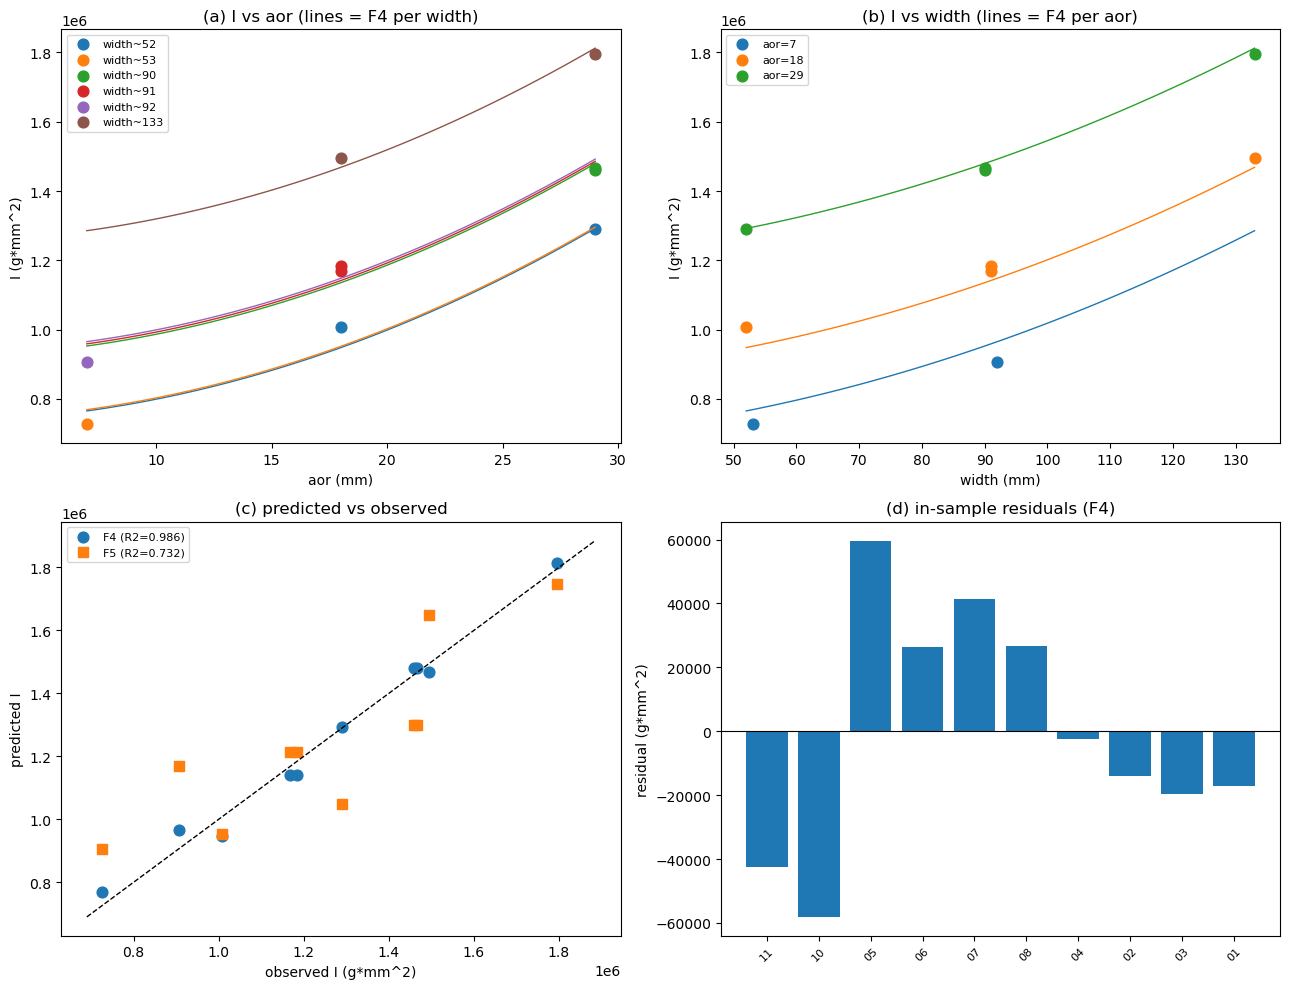

In [5]:
fit_df = df[~df.get('error').notna() if 'error' in df else np.ones(len(df), bool)].copy()
fit_df = fit_df[~fit_df['excluded']].copy()
aor = fit_df['aor_millimeter'].to_numpy(float)
wid = fit_df['width_millimeter'].to_numpy(float)
I = fit_df['i_gram_millimeter_squared'].to_numpy(float)

def predict(form_id, a_arr, w_arr):
    coef = [art['candidate_forms'][form_id]['coefficients'][n] for n in _APPARATUS_FIT_TERMS[form_id]]
    return np.array([np.dot(_apparatus_fit_design_row(form_id, a, w), coef) for a, w in zip(a_arr, w_arr)])

fig, ax = plt.subplots(2, 2, figsize=(13, 10))

# (a) I vs aor, colored by width, with F4 curves per width level
for w0 in sorted(set(np.round(wid).astype(int))):
    m = np.round(wid).astype(int) == w0
    ax[0, 0].scatter(aor[m], I[m], s=60, label=f'width~{w0}')
    a_line = np.linspace(aor.min(), aor.max(), 50)
    ax[0, 0].plot(a_line, predict('F4', a_line, np.full_like(a_line, w0)), lw=1)
ax[0, 0].set(xlabel='aor (mm)', ylabel='I (g*mm^2)', title='(a) I vs aor (lines = F4 per width)')
ax[0, 0].legend(fontsize=8)

# (b) I vs width, colored by aor, with F4 curves per aor level
for a0 in sorted(set(np.round(aor).astype(int))):
    m = np.round(aor).astype(int) == a0
    ax[0, 1].scatter(wid[m], I[m], s=60, label=f'aor={a0}')
    w_line = np.linspace(wid.min(), wid.max(), 50)
    ax[0, 1].plot(w_line, predict('F4', np.full_like(w_line, a0), w_line), lw=1)
ax[0, 1].set(xlabel='width (mm)', ylabel='I (g*mm^2)', title='(b) I vs width (lines = F4 per aor)')
ax[0, 1].legend(fontsize=8)

# (c) predicted vs observed for F4 and F5
for form_id, mk in (('F4', 'o'), ('F5', 's')):
    pred = predict(form_id, aor, wid)
    r2 = art['candidate_forms'][form_id]['r2']
    ax[1, 0].scatter(I, pred, marker=mk, s=60, label=f'{form_id} (R2={r2:.3f})')
lim = [I.min() * 0.95, I.max() * 1.05]
ax[1, 0].plot(lim, lim, 'k--', lw=1)
ax[1, 0].set(xlabel='observed I (g*mm^2)', ylabel='predicted I', title='(c) predicted vs observed')
ax[1, 0].legend(fontsize=8)

# (d) LOO residuals of the selected form
sel = art['fit_form_id']
pred_sel = predict(sel, aor, wid)
resid = I - pred_sel
order = np.argsort(aor * 1000 + wid)
ax[1, 1].bar(range(len(resid)), resid[order])
ax[1, 1].set_xticks(range(len(resid)))
ax[1, 1].set_xticklabels(fit_df['tag'].to_numpy()[order], rotation=45, fontsize=8)
ax[1, 1].axhline(0, color='k', lw=0.8)
ax[1, 1].set(ylabel='residual (g*mm^2)', title=f'(d) in-sample residuals ({sel})')

plt.tight_layout()
plt.savefig('figures/explore_apparatus_inertia.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Assessment

**Findings (2026-07-06 calibration set, 10 trials after excluding `_09_`):**

1. **Inertia grows with both aor and width, coefficients positive.** Selected form **F4**: `I = 638693 + 665.3*aor^2 + 34.7*width^2` (g*mm^2). The constant `a ~ 6.4e5 g*mm^2` is the fixed-position apparatus + clamp self-inertia (present even at aor=width=0), exactly the "part that stays put." Both quadratic coefficients are positive - inertia rises with distance-from-axis and with clamp spread, as physics demands.

2. **The single-mass Pythagorean form F5 does NOT hold.** F5 (R2=0.73) is badly beaten by the unconstrained F4 (R2=0.986); in predicted-vs-observed, F4 hugs the identity line while F5 scatters. The recovered F4 aor^2:width^2 ratio is **~19:1, not the 4:1** the single-lumped-mass hypotenuse geometry predicts (geometry_check.anomaly=True). Physical reading: **aor and width move DIFFERENT masses** - a large carriage/arm mass whose radius scales with aor, plus a much smaller plate mass that spreads with width - so their quadratic terms are independent (b >> c), which is precisely the separable F4, not the constrained F5. This is a sensible two-mass apparatus, not an anomaly to fear; F5's 4:1 lock was the oversimplification.

3. **Accurate enough to trust.** Leave-one-out CV error = **3.79e-3 N*m**, which is **3.4%** of the mean raw zTorque signal RMS (0.111 N*m). In-sample residuals are within ~+/-5% with mild structure at the aor=7 row. No outliers or bad fits flagged (besides the pre-excluded `_09_`). File `_06_` (notes: "off-center") matches its replicate `_07_` and is not an outlier.

4. **Sign must be verified on the rig.** All 10 trials have a negative zTorque-vs-alpha slope (consistent, not mixed). Stored `I` is the magnitude; whether the correction subtracts or adds must be confirmed on hardware (a correct correction reduces acceleration-correlated ripple).

**Conclusion:** the relationship is real, positive, and accurate (~3-4% of signal). Adopt **F4** (separable quadratic), not the constrained F5, as the production form. The physical decomposition (fixed `a`, aor-arm mass, width-plate mass) is coherent. Caveat: aor values are transcribed from lab notes, not yet re-measured; re-run this notebook if they are refined."